## Commits per hour!

In [97]:
import pandas as pd
import sqlite3

In [98]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

query="""
SELECT timestamp
FROM checker
WHERE uid LIKE 'user%';
"""

commit_times=pd.read_sql_query(query, conn)
commit_times.head(10)

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
5,2020-04-17 05:43:18.546760
6,2020-04-17 05:43:27.773992
7,2020-04-17 05:46:22.151752
8,2020-04-17 05:46:32.275104
9,2020-04-17 05:50:17.757425


In [99]:
week_days=[0,1,2,3,4]

commit_times['timestamp']=commit_times['timestamp'].astype('datetime64[ns]')
commit_times['hour']=commit_times['timestamp'].dt.hour
commit_times['day']=commit_times['timestamp'].dt.weekday.apply(lambda x: 'week_day' if x in week_days else 'weekend')
commit_times

,timestamp,hour,day
0,2020-04-17 05:19:02.744528,5,week_day
1,2020-04-17 05:22:35.249331,5,week_day
2,2020-04-17 05:22:45.549397,5,week_day
3,2020-04-17 05:34:14.691200,5,week_day
4,2020-04-17 05:34:24.422370,5,week_day
...,...,...,...
3202,2020-05-21 20:19:06.872761,20,week_day
3203,2020-05-21 20:22:41.785725,20,week_day
3204,2020-05-21 20:22:41.877806,20,week_day
3205,2020-05-21 20:37:00.129678,20,week_day


In [100]:
commit_times.drop(columns=['timestamp'], inplace=True)
commit_times.set_index('hour', inplace=True)
commit_times.head()

,day
hour,
5,week_day
5,week_day
5,week_day
5,week_day
5,week_day


In [101]:
week_days=commit_times.loc[commit_times['day']=='week_day'].groupby(['hour']).count()
weekend=commit_times.loc[commit_times['day']=='weekend'].groupby(['hour']).count()

weekend.rename(columns={'day':'weekend'}, inplace=True)
week_days.rename(columns={'day':'week_day'}, inplace=True)

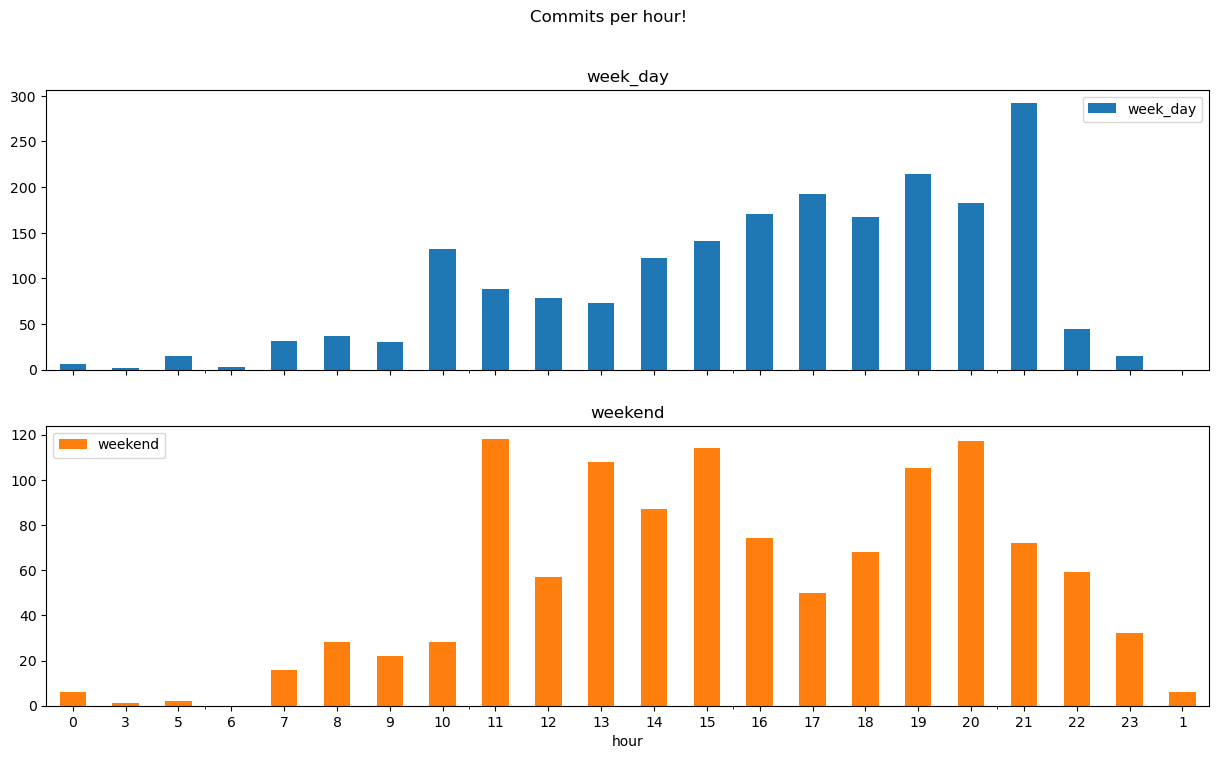

In [102]:
combined=pd.concat([week_days, weekend], axis=1)

ax = combined.plot.bar(title="Commits per hour!", subplots=True, rot=0, figsize=(15, 8))
ax[1].legend(loc=2)

In [103]:
conn.close()